<a href="https://colab.research.google.com/github/FABYG6/Percepci-n_Computacional/blob/main/practica_audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q librosa soundfile
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

In [ ]:
# Cambia el nombre por el archivo que subiste a Colab
audio_path = "audio.wav"
senal, sr = librosa.load(audio_path, sr=None)
print("Frecuencia de muestreo:", sr)
print("Número de muestras:", len(senal))
print("Duración en segundos:", round(len(senal) / sr, 2))

Frecuencia de muestreo: 48000
Número de muestras: 725760
Duración en segundos: 15.12


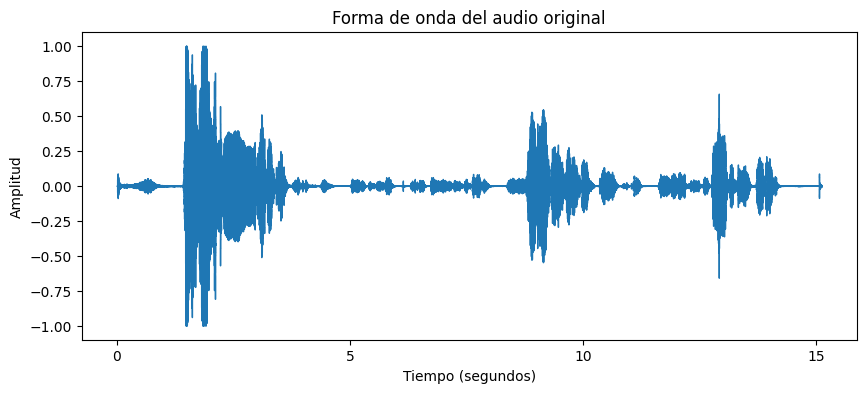

In [ ]:
plt.figure(figsize=(10, 4))
librosa.display.waveshow(senal, sr=sr)
plt.title("Forma de onda del audio original")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.show()

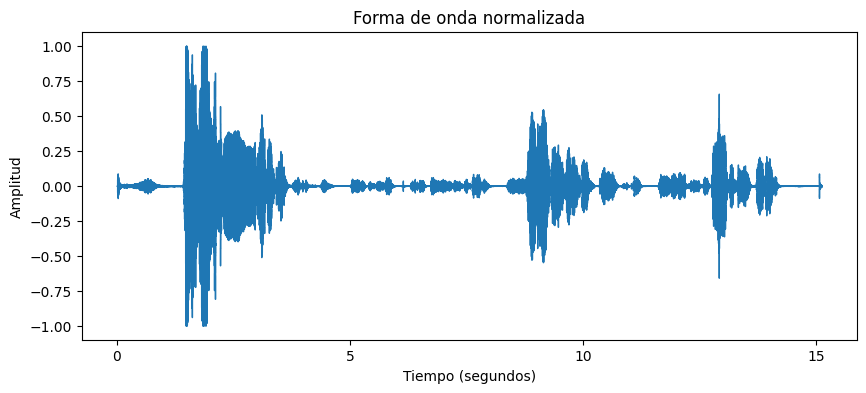

In [ ]:
senal_normalizada = librosa.util.normalize(senal)
plt.figure(figsize=(10, 4))
librosa.display.waveshow(senal_normalizada, sr=sr)
plt.title("Forma de onda normalizada")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.show()

Duración original: 15.12 segundos
Duración después del recorte: 12.66 segundos


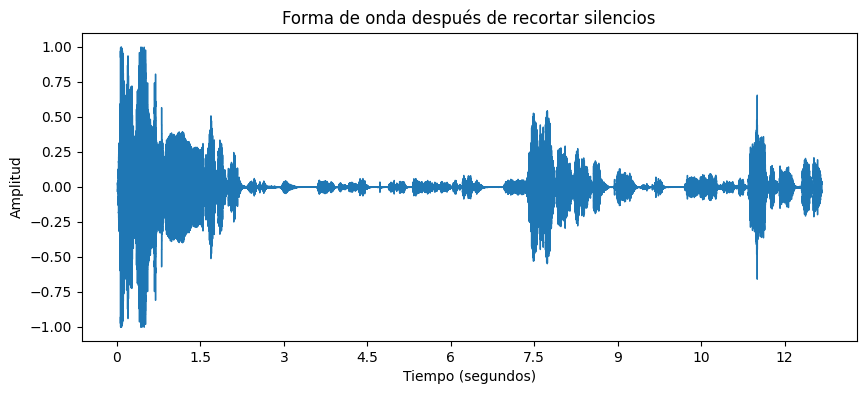

Frecuencia de muestreo: 48000
Número de muestras: 607744


In [ ]:
senal_recortada, indice = librosa.effects.trim(senal_normalizada, top_db=25)
print("Duración original:", round(len(senal_normalizada) / sr, 2), "segundos")
print("Duración después del recorte:", round(len(senal_recortada) / sr, 2), "segundos")
plt.figure(figsize=(10, 4))
librosa.display.waveshow(senal_recortada, sr=sr)
plt.title("Forma de onda después de recortar silencios")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.show()

print("Frecuencia de muestreo:", sr)
print("Número de muestras:", len(senal_recortada))

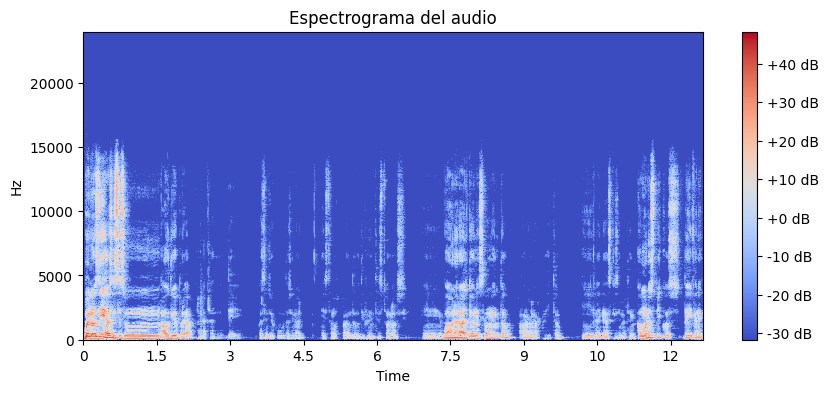

In [ ]:
S = librosa.stft(senal_recortada)
S_db = librosa.amplitude_to_db(abs(S))
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title("Espectrograma del audio")
plt.show()

**Que cambió del sonido original al sonido tratado?**

Comparando con los ejercicos de mis compañeros nos dimos cuenta que los audios originales presentaban una amplitud diferente antes de ser normalizados y todos presentaban recortes de silecion al inicio y al final.


* ¿Qué información básica pudieron obtener del archivo de audio?
Rta:

Frecuencia de muestreo: 48000
Número de muestras: 725760
Duración en segundos: 15.12


* ¿Qué representa la forma de onda?
Rta:

El audio fue grabado con diferentes amplitudes de acuerdo al tono de voz


* ¿Qué cambió después de normalizar la señal?
Rta:
No se aprecian muchos cambios porque el audio original tenia su pico máximo cercano a 1.0 y al normalizarlo lo llevó exactamente a 1.0, por eso las dos gráficas son practiamente idénticas.


La amplitud fue generalizada en todos los momentos del audio.

* ¿Qué ocurrió al recortar silencios?
Rta:

-- El numero de muestras al principio fue de 725 mil y al final de 607 mil
--Se reduce la duración del audio porque quita espacios en silencio al principio y al final.

* ¿Por qué sería importante preparar una señal antes de usar un modelo de inteligencia artificial?

-Porque elimina el ruido y la información irrelevante haciendo que el modelo pierda tiempo procesando partes sin información.


-